# Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [4]:
# Read the CSV file into a DataFrame
crsp = pd.read_csv('/content/drive/MyDrive/Quant/crsp_monthly_returns.csv')
ccm = pd.read_csv("/content/drive/MyDrive/Quant/ccm_quarterly_financials.csv")

#crsp = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Quant/crsp_monthly_returns.csv')
#ccm = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/Quant/ccm_quarterly_financials.csv")

In [5]:
#crsp

In [6]:
# number of unique stocks
crsp['TICKER'].nunique()

20210

# Data Cleaning

In [7]:
# convert date
crsp['date'] = pd.to_datetime(crsp['date'], format='mixed', errors='coerce')

#rename permno for merging later
crsp = crsp.rename(columns={'PERMNO': 'permno'})

# sort
crsp = crsp.sort_values(['permno', 'date'])

# fix returns (include delisting returns)
crsp['RET'] = pd.to_numeric(crsp['RET'], errors='coerce')
crsp['DLRET'] = pd.to_numeric(crsp['DLRET'], errors='coerce')

crsp['ret_adj'] = (1 + crsp['RET'].fillna(0)) * (1 + crsp['DLRET'].fillna(0)) - 1

# price filter (use absolute value)
crsp['PRC'] = crsp['PRC'].abs()

crsp = crsp[crsp['PRC'] >= 5]

# market cap (optional but useful)
# SHROUT = shares outstanding in thousands
crsp['mktcap'] = crsp['PRC'] * crsp['SHROUT'] * 1000

crsp.head()

,permno,date,SHRCD,EXCHCD,TICKER,PERMCO,CUSIP,DLRET,PRC,RET,SHROUT,vwretd,ewretd,sprtrn,ret_adj,mktcap
0,10001,1990-01-31,11,3,GFGC,7953,36720410,NaN,9.9375,-0.018519,1022.0,-0.070114,-0.046408,-0.068817,-0.018519,10156125.0
1,10001,1990-02-28,11,3,GFGC,7953,36720410,NaN,9.8750,-0.006289,1022.0,0.014900,0.015434,0.008539,-0.006289,10092250.0
2,10001,1990-03-30,11,3,GFGC,7953,36720410,NaN,9.8750,0.012658,1027.0,0.024148,0.021315,0.024255,0.012658,10141625.0
3,10001,1990-04-30,11,3,GFGC,7953,36720410,NaN,9.8750,0.000000,1027.0,-0.028283,-0.028116,-0.026887,0.000000,10141625.0
4,10001,1990-05-31,11,3,GFGC,7953,36720410,NaN,9.7500,-0.012658,1027.0,0.088935,0.045673,0.091989,-0.012658,10013250.0


In [8]:
ccm['datadate'] = pd.to_datetime(ccm['datadate'])

# Rename LPERMNO to permno
ccm = ccm.rename(columns={'LPERMNO': 'permno'})

# sort
ccm = ccm.sort_values(['permno', 'datadate'])

ccm.head()

,GVKEY,LINKPRIM,LINKTYPE,permno,LPERMCO,LINKDT,LINKENDDT,datadate,fyearq,fqtr,tic,atq,ltq,niq,saleq,oancfy,sic
251809,12994,P,LC,10001,7953,1986-01-09,2017-08-31,1990-03-31,1990,3,EGAS,20.245,13.002,0.728,8.350,NaN,4924
251810,12994,P,LC,10001,7953,1986-01-09,2017-08-31,1990-06-30,1990,4,EGAS,18.881,11.702,0.035,4.379,NaN,4924
251811,12994,P,LC,10001,7953,1986-01-09,2017-08-31,1990-09-30,1991,1,EGAS,18.403,11.526,-0.322,2.403,NaN,4924
251812,12994,P,LC,10001,7953,1986-01-09,2017-08-31,1990-12-31,1991,2,EGAS,21.710,14.256,0.678,8.495,NaN,4924
251813,12994,P,LC,10001,7953,1986-01-09,2017-08-31,1991-03-31,1991,3,EGAS,21.068,13.014,0.744,8.452,NaN,4924


In [9]:
#lag total assets because we want to compare accurals over the quarter to the company's state at beg of quarter
ccm['atq_lag'] = ccm.groupby('permno')['atq'].shift(1)

#compute quartely cash flows from YTD cash flows
ccm['fyear'] = ccm['datadate'].dt.year

#calculate quarterly operating cash flow
ccm['oancfq_est'] = ccm.groupby('permno')['oancfy'].diff()
# fill Q1 values
ccm.loc[ccm['oancfq_est'].isna(), 'oancfq_est'] = ccm['oancfy']

#alt way of calculating quarterly cf to test feature robustness
#ccm['oancfq_est'] = ccm['oancfy']/4

#compute accurals
ccm['accruals'] = (ccm['niq'] - ccm['oancfq_est']) / ccm['atq_lag']

#winsorize outliters
def winsorize(series, p=0.01):
    lower = series.quantile(p)
    upper = series.quantile(1-p)
    return series.clip(lower, upper)

ccm['accruals'] = winsorize(ccm['accruals'])

#apply reporting lag because company financials are released at end of the quarter
ccm['signal_date'] = ccm['datadate'] + pd.DateOffset(months=3)

#drop bad rows
ccm = ccm.dropna(subset=['accruals', 'atq_lag'])
ccm = ccm[np.isfinite(ccm['accruals'])]
ccm = ccm[(ccm['atq_lag'] > 0)]

In [10]:
ccm

,GVKEY,LINKPRIM,LINKTYPE,permno,LPERMCO,LINKDT,LINKENDDT,datadate,fyearq,fqtr,...,ltq,niq,saleq,oancfy,sic,atq_lag,fyear,oancfq_est,accruals,signal_date
251851,12994,P,LC,10001,7953,1986-01-09,2017-08-31,2000-09-30,2001,1,...,42.876,-0.593,16.419,-4.748,4924,50.553,2000,-4.748,0.082191,2000-12-30
251852,12994,P,LC,10001,7953,1986-01-09,2017-08-31,2000-12-31,2001,2,...,52.297,1.322,28.528,-5.041,4924,56.511,2000,-0.293,0.028579,2001-03-31
251853,12994,P,LC,10001,7953,1986-01-09,2017-08-31,2001-03-31,2001,3,...,51.249,2.581,39.988,-1.365,4924,66.627,2001,3.676,-0.016435,2001-06-30
251854,12994,P,LC,10001,7953,1986-01-09,2017-08-31,2001-06-30,2001,4,...,45.648,-0.545,35.226,6.008,4924,68.008,2001,7.373,-0.116427,2001-09-30
251855,12994,P,LC,10001,7953,1986-01-09,2017-08-31,2001-09-30,2002,1,...,55.604,-0.433,16.808,-7.548,4924,61.261,2001,-13.556,0.214215,2001-12-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869758,184996,P,LC,93436,53453,2010-06-29,E,2023-12-31,2023,4,...,43009.000,7928.000,25167.000,13256.000,3711,93941.000,2023,4370.000,0.037875,2024-03-31
869759,184996,P,LC,93436,53453,2010-06-29,E,2024-03-31,2024,1,...,44046.000,1390.000,21301.000,242.000,3711,106618.000,2024,-13014.000,0.135099,2024-06-30
869760,184996,P,LC,93436,53453,2010-06-29,E,2024-06-30,2024,2,...,45569.000,1400.000,25500.000,3854.000,3711,109226.000,2024,3612.000,-0.020252,2024-09-30
869761,184996,P,LC,93436,53453,2010-06-29,E,2024-09-30,2024,3,...,49142.000,2173.000,25182.000,10109.000,3711,112832.000,2024,6255.000,-0.036178,2024-12-30


# Merge CCM with CRSP

In [11]:
ccm = ccm[['permno', 'signal_date', 'accruals']]

ccm = ccm.sort_values(['permno', 'signal_date'])

merged = pd.merge_asof(
    crsp.sort_values('date'),
    ccm.sort_values('signal_date'),
    left_on='date',
    right_on='signal_date',
    by='permno',
    direction='backward'
)

In [12]:
merged = merged.dropna(subset=['accruals'])
merged

,permno,date,SHRCD,EXCHCD,TICKER,PERMCO,CUSIP,DLRET,PRC,RET,SHROUT,vwretd,ewretd,sprtrn,ret_adj,mktcap,signal_date,accruals
21189,60548,1990-07-31,11,2,MPR,3023,59087630,NaN,20.00000,-0.157895,2911.0,-0.009392,-0.025731,-0.005223,-0.157895,5.822000e+07,1990-07-30,-0.003729
21199,80179,1990-07-31,11,3,VALU,5974,92043710,NaN,18.25000,-0.109756,9958.0,-0.009392,-0.025731,-0.005223,-0.109756,1.817335e+08,1990-07-30,0.002699
21226,53495,1990-07-31,11,2,KPI,21054,49412510,NaN,5.00000,0.000000,1429.0,-0.009392,-0.025731,-0.005223,0.000000,7.145000e+06,1990-07-30,-0.010731
21229,10514,1990-07-31,11,3,TWMC,8431,48583710,NaN,31.25000,0.000000,9058.0,-0.009392,-0.025731,-0.005223,0.000000,2.830625e+08,1990-07-30,0.279034
21230,13777,1990-07-31,11,3,AMSWA,5828,02968310,NaN,14.12500,-0.181159,17286.0,-0.009392,-0.025731,-0.005223,-0.181159,2.441648e+08,1990-07-30,-0.004086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551922,20391,2024-12-31,11,1,TPL,57695,88262P10,NaN,1105.95996,-0.307814,22975.0,-0.031582,-0.021978,-0.024990,-0.307814,2.540943e+10,2024-12-30,-0.009096
1551923,20365,2024-12-31,11,1,BODI,57540,07346330,NaN,6.15000,-0.042056,4195.0,-0.031582,-0.021978,-0.024990,-0.042056,2.579925e+07,2024-12-30,-0.053417
1551924,20357,2024-12-31,11,1,IONQ,57538,46222L10,NaN,41.77000,0.144384,216392.0,-0.031582,-0.021978,-0.024990,0.144384,9.038694e+09,2024-12-30,-0.064327
1551925,20567,2024-12-31,11,3,ELTX,57905,28657F10,NaN,5.10000,0.001965,10791.0,-0.031582,-0.021978,-0.024990,0.001965,5.503410e+07,2024-12-30,-0.610797


In [13]:
#visualize signal date is always 0-3 months before return date
merged[merged['TICKER'] == 'TSLA']

,permno,date,SHRCD,EXCHCD,TICKER,PERMCO,CUSIP,DLRET,PRC,RET,SHROUT,vwretd,ewretd,sprtrn,ret_adj,mktcap,signal_date,accruals
1049270,93436,2010-12-31,11,3,TSLA,53453,88160R10,NaN,26.63000,-0.246250,94908.0,0.067182,0.068851,0.065300,-0.246250,2.527400e+09,2010-12-30,0.090611
1051875,93436,2011-01-31,11,3,TSLA,53453,88160R10,NaN,24.10000,-0.095006,94908.0,0.019183,0.014412,0.022646,-0.095006,2.287283e+09,2010-12-30,0.090611
1054318,93436,2011-02-28,11,3,TSLA,53453,88160R10,NaN,23.89000,-0.008714,95335.0,0.038156,0.037036,0.031957,-0.008714,2.277553e+09,2010-12-30,0.090611
1058869,93436,2011-03-31,11,3,TSLA,53453,88160R10,NaN,27.75000,0.161574,95555.0,0.003341,0.008605,-0.001047,0.161574,2.651651e+09,2011-03-31,-0.047215
1061611,93436,2011-04-29,11,3,TSLA,53453,88160R10,NaN,27.60000,-0.005405,95633.0,0.028597,0.019203,0.028495,-0.005405,2.639471e+09,2011-03-31,-0.047215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1539418,93436,2024-08-30,11,3,TSLA,53453,88160R10,NaN,214.11000,-0.077390,3194640.0,0.021572,-0.010883,0.022835,-0.077390,6.840044e+11,2024-06-30,0.135099
1541099,93436,2024-09-30,11,3,TSLA,53453,88160R10,NaN,261.63000,0.221942,3207000.0,0.020969,0.016322,0.020197,0.221942,8.390474e+11,2024-09-30,-0.020252
1543711,93436,2024-10-31,11,3,TSLA,53453,88160R10,NaN,249.85001,-0.045025,3210060.0,-0.008298,-0.005589,-0.009897,-0.045025,8.020335e+11,2024-09-30,-0.020252
1547678,93436,2024-11-29,11,3,TSLA,53453,88160R10,NaN,345.16000,0.381469,3210060.0,0.064855,0.063684,0.057301,0.381469,1.107984e+12,2024-09-30,-0.020252


# Signal Formation

In [14]:
# Step 1 — Define Features (Signals)

# Calculate Size (natural log of market cap)
merged['size'] = np.log(merged['mktcap'])

# Calculate Momentum (past 12–1 returns)
# (1+R) terms for compounding
merged['1_plus_ret_adj'] = 1 + merged['ret_adj']

# Calculate 12-month compounded returns (ending at current month t)
# This will be (1+R_t) * (1+R_{t-1}) * ... * (1+R_{t-11})
# .reset_index(level=0, drop=True) is crucial to align the Series index with `merged`
merged['momentum_raw_product'] = merged.groupby('permno')['1_plus_ret_adj'].rolling(window=12).apply(np.prod, raw=False).reset_index(level=0, drop=True)

# Shift by 1 to get the 12-1 momentum: (1+R_{t-1}) * ... * (1+R_{t-12}) - 1
merged['momentum'] = merged.groupby('permno')['momentum_raw_product'].shift(1) - 1

# Drop temporary columns
merged = merged.drop(columns=['1_plus_ret_adj', 'momentum_raw_product'])

# Step 2 — Standardize Features (VERY IMPORTANT)
# At each month: zscore each feature cross-sectionally
# Clip / winsorize signals at -3, 3 standard deviations

# Define the features to standardize (accruals is already in merged from ccm merge)
features_to_standardize = ['accruals', 'momentum', 'size']

# Ensure accruals column exists before processing
if 'accruals' not in merged.columns:
    print("Warning: The 'accruals' column is missing from the merged DataFrame. Please ensure it's calculated before this step.")

for feature in features_to_standardize:
    # Calculate cross-sectional Z-score using transform
    # Handle potential division by zero for std=0 (results in NaN where values are constant)
    merged[f'{feature}_zscore'] = merged.groupby('date')[feature].transform(lambda x: (x - x.mean()) / x.std())

    # Clip / winsorize Z-scores at -3 and 3
    merged[f'{feature}_signal'] = np.clip(merged[f'{feature}_zscore'], -3, 3)

    # Drop temporary zscore column
    merged = merged.drop(columns=[f'{feature}_zscore'], errors='ignore')

# Drop the original raw feature columns if only the signals are needed for the next steps
merged = merged.drop(columns=features_to_standardize, errors='ignore')

In [22]:
# Prepare target: Lead the returns by one month
merged = merged.sort_values(['permno', 'date'])
merged['ret_lead'] = merged.groupby('permno')['ret_adj'].shift(-1)

# Define our features
signal_cols = ['accruals_signal', 'momentum_signal', 'size_signal']

def run_monthly_regression(group):
    if len(group) < 10:
        return pd.Series([np.nan] * (len(signal_cols) + 1), index=['const'] + signal_cols)

    y = group['ret_lead']
    X = sm.add_constant(group[signal_cols])

    valid = y.notna() & X.notna().all(axis=1)
    if valid.sum() < 10:
        return pd.Series([np.nan] * (len(signal_cols) + 1), index=['const'] + signal_cols)

    try:
        model = sm.OLS(y[valid], X[valid]).fit()
        return model.params
    except:
        return pd.Series([np.nan] * (len(signal_cols) + 1), index=['const'] + signal_cols)

# Step 3 — Cross-Sectional Regression (Training)
print("Running monthly regressions...")
monthly_betas_raw = merged.groupby('date').apply(run_monthly_regression, include_groups=False)
monthly_betas_df = monthly_betas_raw.unstack() if isinstance(monthly_betas_raw.index, pd.MultiIndex) else monthly_betas_raw

# Calculate the 10-year (120 month) rolling average of betas
# CHANGED: min_periods set to 120 to enforce strict 10-year window
rolling_betas = monthly_betas_df.rolling(window=120, min_periods=120).mean()

# Shift the betas so that for trading in month T, we use the average betas calculated up to T-1
trading_betas = rolling_betas.shift(1).reset_index()

# Rename columns to match the signal calculation
rename_map = {col: f"{col}_beta" for col in (['const'] + signal_cols)}
trading_betas = trading_betas.rename(columns=rename_map)
trading_betas = trading_betas.rename(columns={'const_beta': 'intercept_beta'})

# Merge these trading betas back into the main dataframe
beta_cols = [c for c in trading_betas.columns if c != 'date']
merged = merged.drop(columns=[c for c in beta_cols if c in merged.columns], errors='ignore')
merged = merged.merge(trading_betas, on='date', how='left')

# Calculate the combined signal score
merged['combined_score'] = (
    merged['accruals_signal'] * merged.get('accruals_signal_beta', 0) +
    merged['momentum_signal'] * merged.get('momentum_signal_beta', 0) +
    merged['size_signal'] * merged.get('size_signal_beta', 0) +
    merged.get('intercept_beta', 0)
)

# Drop rows where we don't have a score yet
regression_results_df = merged.dropna(subset=['combined_score'])
display(regression_results_df[['date', 'TICKER', 'combined_score']].head())

Running monthly regressions...


,date,TICKER,combined_score
12,2002-01-31,EWST,0.023163
13,2002-02-28,EWST,0.023269
14,2002-03-28,EWST,0.024551
15,2002-04-30,EWST,0.037696
16,2002-05-31,EWST,0.037535


In [16]:
merged

,permno,date,SHRCD,EXCHCD,TICKER,PERMCO,CUSIP,DLRET,PRC,RET,...,signal_date,accruals_signal,momentum_signal,size_signal,ret_lead,intercept_beta,accruals_signal_beta,momentum_signal_beta,size_signal_beta,combined_score
0,10001,2001-01-31,11,3,EWST,7953,36720410,NaN,9.87500,0.012821,...,2000-12-30,1.153378,NaN,-1.631085,-0.012658,0.022337,-0.004847,0.003097,-0.008250,NaN
1,10001,2001-02-28,11,3,EWST,7953,36720410,NaN,9.75000,-0.012658,...,2000-12-30,1.236927,NaN,-1.640604,0.038462,0.021764,-0.004812,0.003132,-0.008500,NaN
2,10001,2001-03-30,11,3,EWST,7953,36720410,NaN,10.00000,0.038462,...,2000-12-30,1.215189,NaN,-1.641605,-0.025000,0.021332,-0.004771,0.003118,-0.008754,NaN
3,10001,2001-04-30,11,3,EWST,7953,36720410,NaN,9.75000,-0.025000,...,2001-03-31,0.587830,NaN,-1.674550,0.097436,0.022025,-0.004759,0.002729,-0.008553,NaN
4,10001,2001-05-31,11,3,EWST,7953,36720410,NaN,10.70000,0.097436,...,2001-03-31,0.616677,NaN,-1.638642,0.114953,0.022368,-0.004728,0.002758,-0.008782,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1300392,93436,2024-08-30,11,3,TSLA,53453,88160R10,NaN,214.11000,-0.077390,...,2024-06-30,0.755191,-0.573238,2.826745,0.221942,0.016012,-0.003128,-0.000797,-0.006686,-0.004794
1300393,93436,2024-09-30,11,3,TSLA,53453,88160R10,NaN,261.63000,0.221942,...,2024-09-30,-0.193576,-0.645511,2.911119,-0.045025,0.016452,-0.003090,-0.000756,-0.006670,-0.001879
1300394,93436,2024-10-31,11,3,TSLA,53453,88160R10,NaN,249.85001,-0.045025,...,2024-09-30,-0.148306,-0.373210,2.897833,0.381469,0.016033,-0.003244,-0.000632,-0.006729,-0.002749
1300395,93436,2024-11-29,11,3,TSLA,53453,88160R10,NaN,345.16000,0.381469,...,2024-09-30,-0.144594,-0.196916,3.000000,0.170008,0.016795,-0.003275,-0.000637,-0.006811,-0.003039


### Step 4 — Generate Expected Returns (Out-of-Sample)

We apply the rolling coefficients (the $\beta$s) to the current signals to forecast the next period's returns.

$$\hat{R}_{i,t+1} = \beta_{0,t} + \beta_{accruals,t} \cdot Accruals_{i,t} + \beta_{mom,t} \cdot Mom_{i,t} + \beta_{size,t} \cdot Size_{i,t}$$

Where the $\beta$ values used for prediction at time $t$ are the average of historical $\beta$s from $t-121$ to $t-1$.

In [24]:
# The 'combined_score' calculated in the previous cell is our Expected Return (R_hat).
# We will explicitly rename it for clarity and inspect the results for the most recent periods.

merged['expected_return'] = merged['combined_score']

# Display the top stocks by expected return for the most recent available date
latest_date = merged['date'].max()
print(f"Top 10 Stocks by Expected Return for {latest_date.date()}:")
display(merged[merged['date'] == latest_date].sort_values('expected_return', ascending=False)[['TICKER', 'expected_return', 'accruals_signal', 'momentum_signal', 'size_signal']].head(10))

Top 10 Stocks by Expected Return for 2024-12-31:


,TICKER,expected_return,accruals_signal,momentum_signal,size_signal
923734,ASTC,0.043968,-3.000000,-0.585591,-2.574132
219709,ADN,0.043859,-3.000000,-1.007419,-2.504313
231939,MNTS,0.043211,-3.000000,-1.307499,-2.370616
1269757,SCOR,0.038455,-2.187119,-0.847828,-2.124717
231989,ANVS,0.038036,-3.000000,-0.674930,-1.688802
1300223,SANW,0.037839,-2.519314,2.862685,-2.344706
535246,USAU,0.037067,-3.000000,0.118965,-1.647166
250573,ELTX,0.036466,-3.000000,2.034923,-1.802682
1128236,PRPO,0.036450,-0.392107,-0.591897,-2.736932
269514,CTGO,0.036272,-3.000000,-0.826188,-1.409676


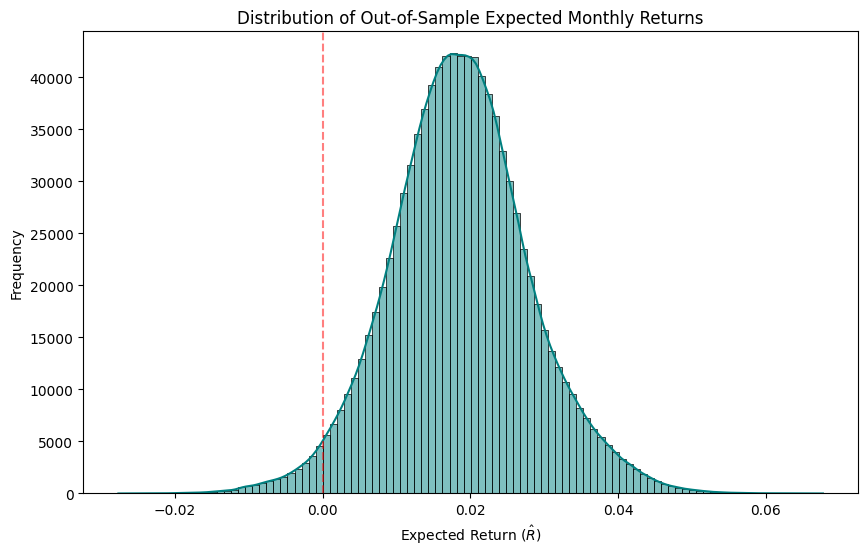

In [18]:
plt.figure(figsize=(10, 6))
# Use combined_score directly as it is the expected return
sns.histplot(merged['combined_score'].dropna(), bins=100, kde=True, color='teal')
plt.title('Distribution of Out-of-Sample Expected Monthly Returns')
plt.xlabel(r'Expected Return ($\hat{R}$)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.show()

Fama-MacBeth Regression Summary (N=401 months):


,mean_beta,t_stat,p_value
const,0.0185,7.8364,0.0000
accruals_signal,-0.0035,-10.2928,0.0000
momentum_signal,-0.0005,-0.4198,0.6749
size_signal,-0.0077,-14.1426,0.0000


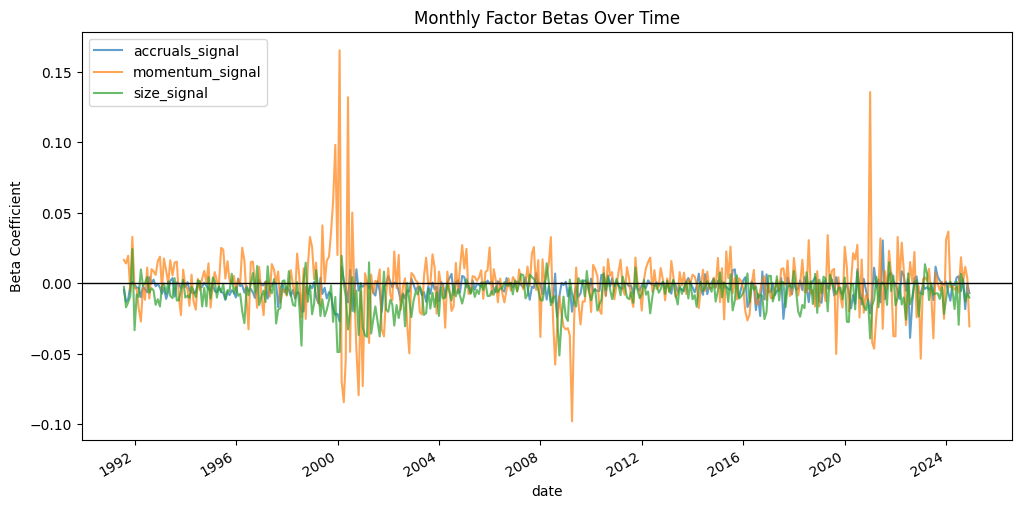

In [19]:
from scipy import stats

# Calculate the time-series mean of the monthly betas
betas_summary = monthly_betas_df.mean().to_frame('mean_beta')

# Calculate t-statistics and p-values for each factor
# Standard error is the time-series std dev divided by sqrt(N)
n_months = len(monthly_betas_df.dropna())
t_stats = monthly_betas_df.mean() / (monthly_betas_df.std() / np.sqrt(n_months))
p_values = [stats.t.sf(np.abs(t), df=n_months-1) * 2 for t in t_stats]

betas_summary['t_stat'] = t_stats
betas_summary['p_value'] = p_values

print(f"Fama-MacBeth Regression Summary (N={n_months} months):")
display(betas_summary.round(4))

# Visualize the distribution of the betas over time
monthly_betas_df[signal_cols].plot(figsize=(12, 6), alpha=0.7)
plt.axhline(0, color='black', lw=1)
plt.title('Monthly Factor Betas Over Time')
plt.ylabel('Beta Coefficient')
plt.legend(loc='best')
plt.show()

# Portfolio Construction

In [27]:
# Filter data for January 2001
jan_2001_data = merged[merged['date'] == '2001-07-31'].dropna(subset=['expected_return'])

# Calculate the 90th percentile threshold
cutoff = jan_2001_data['expected_return'].quantile(0.9)

# Identify the top 10% group
top_10_percent_group = jan_2001_data[jan_2001_data['expected_return'] >= cutoff]

# Count the number of stocks
num_stocks = len(top_10_percent_group)

print(f"Expected Return Cutoff for top 10% (Jan 2001): {cutoff:.4f}")
print(f"Number of stocks in the top 10% group: {num_stocks}")

# Display the top 10 stocks in this group for inspection
display(top_10_percent_group.sort_values('expected_return', ascending=False)[['TICKER', 'expected_return']].head(10))

Expected Return Cutoff for top 10% (Jan 2001): 0.0353
Number of stocks in the top 10% group: 287


,TICKER,expected_return
1031636,DMI,0.056546
825079,NSTK,0.053496
1041725,NICH,0.053266
722969,MWAV,0.052745
812827,ALHY,0.052669
658564,PLCC,0.052018
995844,ECSI,0.051750
1078636,ISMT,0.051205
844919,STRD,0.050649
242721,EMEX,0.050289


In [26]:
def compute_rank_weights(group, c=0.5):
    # 1. Take top and bottom 10%
    group = group.dropna(subset=['expected_return'])
    if group.empty:
        return group

    q_high = group['expected_return'].quantile(0.9)
    q_low = group['expected_return'].quantile(0.1)

    longs = group[group['expected_return'] >= q_high].copy()
    shorts = group[group['expected_return'] <= q_low].copy()

    # 2. Long Side Weighting
    if not longs.empty:
        # Rank: worst long candidate = 1, best = N
        longs['rank_within'] = longs['expected_return'].rank(method='first', ascending=True)
        N_L = len(longs)
        # Convert to percentile p_i = (r_i - 1) / (N - 1)
        if N_L > 1:
            longs['p_i'] = (longs['rank_within'] - 1) / (N_L - 1)
        else:
            longs['p_i'] = 1.0
        # score_i = p_i + c
        longs['score_i'] = longs['p_i'] + c
        # w_i = scores / sum(scores)
        longs['weight'] = longs['score_i'] / longs['score_i'].sum()

    # 3. Short Side Weighting
    if not shorts.empty:
        # Rank: least bad short = 1, worst short = N (best return to worst return)
        shorts['rank_within'] = shorts['expected_return'].rank(method='first', ascending=False)
        N_S = len(shorts)
        if N_S > 1:
            shorts['p_i'] = (shorts['rank_within'] - 1) / (N_S - 1)
        else:
            shorts['p_i'] = 1.0
        shorts['score_i'] = shorts['p_i'] + c
        # w_i = -scores / sum(scores)
        shorts['weight'] = -shorts['score_i'] / shorts['score_i'].sum()

    return pd.concat([longs, shorts])

# Apply monthly rebalancing logic
print("Constructing portfolios with percentile-rank weights...")
portfolio_data = merged.groupby('date').apply(compute_rank_weights, include_groups=False).reset_index()

# Calculate monthly strategy returns
# Strategy return = sum(weight_i * ret_adj_i) for each month
strategy_perf = portfolio_data.groupby('date').apply(lambda x: (x['weight'] * x['ret_adj']).sum())

print("Strategy construction complete.")
display(portfolio_data[['date', 'TICKER', 'expected_return', 'weight']].head())

Constructing portfolios with percentile-rank weights...
Strategy construction complete.


/tmp/ipykernel_5817/2047657240.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  strategy_perf = portfolio_data.groupby('date').apply(lambda x: (x['weight'] * x['ret_adj']).sum())


,date,TICKER,expected_return,weight
0,2001-07-31,RMCF,0.049689,0.005105
1,2001-07-31,DJCO,0.042957,0.004605
2,2001-07-31,SUND,0.036796,0.002680
3,2001-07-31,BNT,0.035433,0.001852
4,2001-07-31,LAKE,0.042787,0.004569


# Compute Returns


In [ ]:
# Calculate the `relevant_formation_year` for each row in `merged`
# This identifies which formation year's signal is active for a given date.
# Signals are formed in June of year Y, and apply from July of year Y to June of year Y+1.
merged['relevant_formation_year'] = merged['date'].dt.year.astype('int64')
# If the date is before July (months 1-6), the relevant formation year is the previous year.
merged.loc[merged['date'].dt.month < 7, 'relevant_formation_year'] = (merged['date'].dt.year - 1).astype('int64')

# Prepare formation market caps and ranks for merging
# The 'year' column in `formation` represents the year the portfolio was formed (June of that year).
# We need `permno`, `year`, `mktcap` (at formation), and `rank` from the `formation` DataFrame.
formation_for_weights_and_ranks = formation[['permno', 'year', 'mktcap', 'rank']].copy()
formation_for_weights_and_ranks.rename(columns={'year': 'formation_year', 'mktcap': 'mktcap_at_formation'}, inplace=True);

# Calculate the total market cap for each portfolio (quintile) at formation
formation_for_weights_and_ranks['total_mktcap_portfolio_at_formation'] = formation_for_weights_and_ranks.groupby(['formation_year', 'rank'])['mktcap_at_formation'].transform('sum')

# Calculate the weight for each stock at formation. These weights are fixed for the next year.
formation_for_weights_and_ranks['weight'] = formation_for_weights_and_ranks['mktcap_at_formation'] / formation_for_weights_and_ranks['total_mktcap_portfolio_at_formation']

# Select only the necessary columns from the formation_for_weights_and_ranks for merging into `merged`
# These are the `permno`, `formation_year`, `rank`, and the newly calculated `weight`
columns_to_merge_from_formation = ['permno', 'formation_year', 'rank', 'weight']
formation_data_to_merge = formation_for_weights_and_ranks[columns_to_merge_from_formation].copy()

# Drop existing 'rank', 'formation_year', and 'weight' columns from `merged` to ensure we use the newly calculated ones
merged = merged.drop(columns=['rank', 'formation_year', 'weight'], errors='ignore')

# Perform the merge using 'permno' and the relevant year.
# This merge will bring the 'rank' and the 'weight' (calculated at formation) into the 'merged' DataFrame.
# The 'formation_year' from `formation_data_to_merge` will align with `relevant_formation_year` in `merged`.
merged = pd.merge(
    merged,
    formation_data_to_merge,
    left_on=['permno', 'relevant_formation_year'],
    right_on=['permno', 'formation_year'],
    how='left'
)

# Ensure only stocks with a valid rank and weight are included in portfolio construction
merged = merged.dropna(subset=['rank', 'weight'])
merged['rank'] = merged['rank'].astype(int) # Ensure rank is integer

# Initialize a dictionary to store returns for each quintile
all_quintile_returns = {}

# Compute value weighted (based on market cap at formation) portfolio returns for each quintile
for quintile_num in range(10):
    quintile_df = merged[merged['rank'] == quintile_num].copy()

    if not quintile_df.empty:
        # Calculate returns for the current quintile using the pre-calculated weights
        # The 'weight' column now holds the fixed weights calculated at formation.
        all_quintile_returns[f'quintile_{quintile_num}_returns'] = (quintile_df['weight'] * quintile_df['ret_adj']).groupby(quintile_df['date']).sum()
    else:
        all_quintile_returns[f'quintile_{quintile_num}_returns'] = pd.Series(dtype=float)


# Convert the dictionary of series to a DataFrame for easier handling
quintile_returns_df = pd.DataFrame(all_quintile_returns)

# Define long_returns (quintile 0) and short_returns (quintile 4) from the new DataFrame
long_returns = quintile_returns_df['quintile_0_returns']
short_returns = quintile_returns_df['quintile_9_returns']

# Calculate the long-minus-short strategy returns
strategy_returns = long_returns - short_returns

#### Transaction Costs

In [ ]:
# turn on transaction costs

# Define transaction costs (20 bps per month)
tc_per_month = 0.002

# Compute net returns for each quintile
quintile_returns_df = quintile_returns_df - tc_per_month

# Compute net returns for the long-short strategy
# Strategy returns are already (Long - Short), so we subtract TC
strategy_returns = strategy_returns - tc_per_month

In [ ]:
quintile_returns_df

,quintile_0_returns,quintile_1_returns,quintile_2_returns,quintile_3_returns,quintile_4_returns,quintile_5_returns,quintile_6_returns,quintile_7_returns,quintile_8_returns,quintile_9_returns
date,,,,,,,,,,
1991-07-31,0.052583,0.060360,0.027953,0.045545,0.046132,0.035749,0.047001,0.050521,0.049202,0.049359
1991-08-30,0.043563,0.019271,0.016584,0.028114,0.017914,0.016801,0.008960,0.029077,0.015016,0.030269
1991-09-30,0.001327,-0.038837,-0.023084,-0.020938,-0.007957,-0.017206,-0.018763,-0.005709,-0.003294,-0.023490
1991-10-31,-0.010890,0.009483,0.005797,0.007034,0.028591,0.013601,0.003026,0.023723,0.030040,0.046577
1991-11-29,-0.056391,-0.015061,-0.054476,-0.041262,-0.027250,-0.056890,-0.043195,-0.034418,-0.048235,-0.056177
...,...,...,...,...,...,...,...,...,...,...
2024-08-30,-0.020204,0.048117,0.005013,0.027779,0.023674,0.031492,0.020855,0.011306,0.009335,0.028248
2024-09-30,0.035220,0.025288,0.021884,0.041081,0.015447,0.007779,0.015985,-0.006158,0.016420,0.017933
2024-10-31,-0.003327,0.009917,0.003285,-0.021333,-0.008972,-0.006368,-0.024509,-0.000308,0.011712,-0.033996


In [ ]:
strategy_returns

,0
date,
1991-07-31,0.001224
1991-08-30,0.011294
1991-09-30,0.022817
1991-10-31,-0.059468
1991-11-29,-0.002214
...,...
2024-08-30,-0.050452
2024-09-30,0.015287
2024-10-31,0.028668


In [ ]:
merged

,permno,date,SHRCD,EXCHCD,TICKER,PERMCO,CUSIP,DLRET,PRC,RET,...,sprtrn,ret_adj,mktcap,signal_date,accruals,year,relevant_formation_year,formation_year,rank,weight
22577,24803,1991-07-31,11,1,WIN,21926,97428010,NaN,36.12500,-0.056026,...,0.044859,-0.056026,2.806298e+09,1991-06-30,-0.048590,1991,1991,1991.0,6,0.011795
22578,10107,1991-07-31,11,3,MSFT,8048,59491810,NaN,73.50000,0.078899,...,0.044859,0.078899,1.280620e+10,1991-06-30,-0.019766,1991,1991,1991.0,7,0.060987
22579,59185,1991-07-31,11,3,OILC,3348,67786410,NaN,17.75000,-0.202247,...,0.044859,-0.202247,8.827075e+07,1991-07-30,-0.031008,1991,1991,1991.0,6,0.000425
22580,10514,1991-07-31,11,3,TWMC,8431,48583710,NaN,16.50000,-0.057143,...,0.044859,-0.057143,1.498530e+08,1991-07-30,0.175218,1991,1991,1991.0,0,0.001761
22581,70893,1991-07-31,11,2,NLN,21273,64646510,NaN,10.12500,-0.068966,...,0.044859,-0.068966,1.208824e+08,1991-06-30,-0.503292,1991,1991,1991.0,9,0.001051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1300391,20395,2024-12-31,11,3,CVBF,5856,12660010,NaN,21.41000,-0.077284,...,-0.024990,-0.077284,2.990506e+09,2024-12-30,-0.001249,2024,2024,2024.0,7,0.001316
1300392,20391,2024-12-31,11,1,TPL,57695,88262P10,NaN,1105.95996,-0.307814,...,-0.024990,-0.307814,2.540943e+10,2024-12-30,-0.009096,2024,2024,2024.0,7,0.009224
1300393,20365,2024-12-31,11,1,BODI,57540,07346330,NaN,6.15000,-0.042056,...,-0.024990,-0.042056,2.579925e+07,2024-12-30,-0.053417,2024,2024,2024.0,0,0.000011
1300394,20357,2024-12-31,11,1,IONQ,57538,46222L10,NaN,41.77000,0.144384,...,-0.024990,0.144384,9.038694e+09,2024-12-30,-0.064327,2024,2024,2024.0,3,0.000241


# Performance Testing

### Turnover Calculation

In [ ]:
import numpy as np

# Assuming 'formation_for_weights_and_ranks' DataFrame is available and correctly structured
# with 'permno', 'formation_year', 'rank', and 'weight' columns.

all_quintile_turnover = {}

for quintile_num in range(10):
    # 1. Filter for the current quintile's stocks
    quintile_data = formation_for_weights_and_ranks[formation_for_weights_and_ranks['rank'] == quintile_num].copy()

    if not quintile_data.empty:
        # 2. Select relevant columns: permno, formation_year, and weight
        quintile_weights_yearly = quintile_data[['permno', 'formation_year', 'weight']].drop_duplicates()

        # 3. Prepare current and previous year weight dataframes for merging
        current_year_weights = quintile_weights_yearly.rename(columns={'weight': 'current_weight'})
        previous_year_weights = quintile_weights_yearly.rename(columns={'weight': 'previous_weight'})

        # Shift the 'formation_year' in the previous_year_weights DataFrame to align it for merging
        previous_year_weights['formation_year'] = previous_year_weights['formation_year'] + 1

        # 4. Perform an outer merge to capture stocks that are present in either the current or previous year
        merged_turnover_data = pd.merge(
            current_year_weights,
            previous_year_weights,
            on=['permno', 'formation_year'],
            how='outer',
            suffixes=('_current', '_prev')
        )

        # 5. Fill NaN weights with 0, as a stock not present in a given year within the quintile implies a weight of 0.
        merged_turnover_data['current_weight'] = merged_turnover_data['current_weight'].fillna(0)
        merged_turnover_data['previous_weight'] = merged_turnover_data['previous_weight'].fillna(0)

        # 6. Calculate the absolute change in weight for each stock-year combination
        merged_turnover_data['abs_weight_change'] = abs(merged_turnover_data['current_weight'] - merged_turnover_data['previous_weight'])

        # 7. Aggregate the absolute weight changes by formation_year to get the annual turnover
        annual_turnover_quintile = merged_turnover_data.groupby('formation_year')['abs_weight_change'].sum()

        # Ensure the index is integer for cleaner display
        annual_turnover_quintile.index = annual_turnover_quintile.index.astype(int)

        all_quintile_turnover[f'Quintile {quintile_num}'] = annual_turnover_quintile
    else:
        all_quintile_turnover[f'Quintile {quintile_num}'] = pd.Series(dtype=float) # Handle empty quintiles

# Convert the dictionary of series to a DataFrame for easier comparison
turnover_df = pd.DataFrame(all_quintile_turnover)

In [ ]:
# Calculate the average turnover for each quintile across all years
avg_turnover_per_quintile = turnover_df.mean()
avg_turnover_per_quintile.name = 'Average Turnover'

# Append this average row to the turnover_df
turnover_df_with_avg = pd.concat([turnover_df, avg_turnover_per_quintile.to_frame().T])

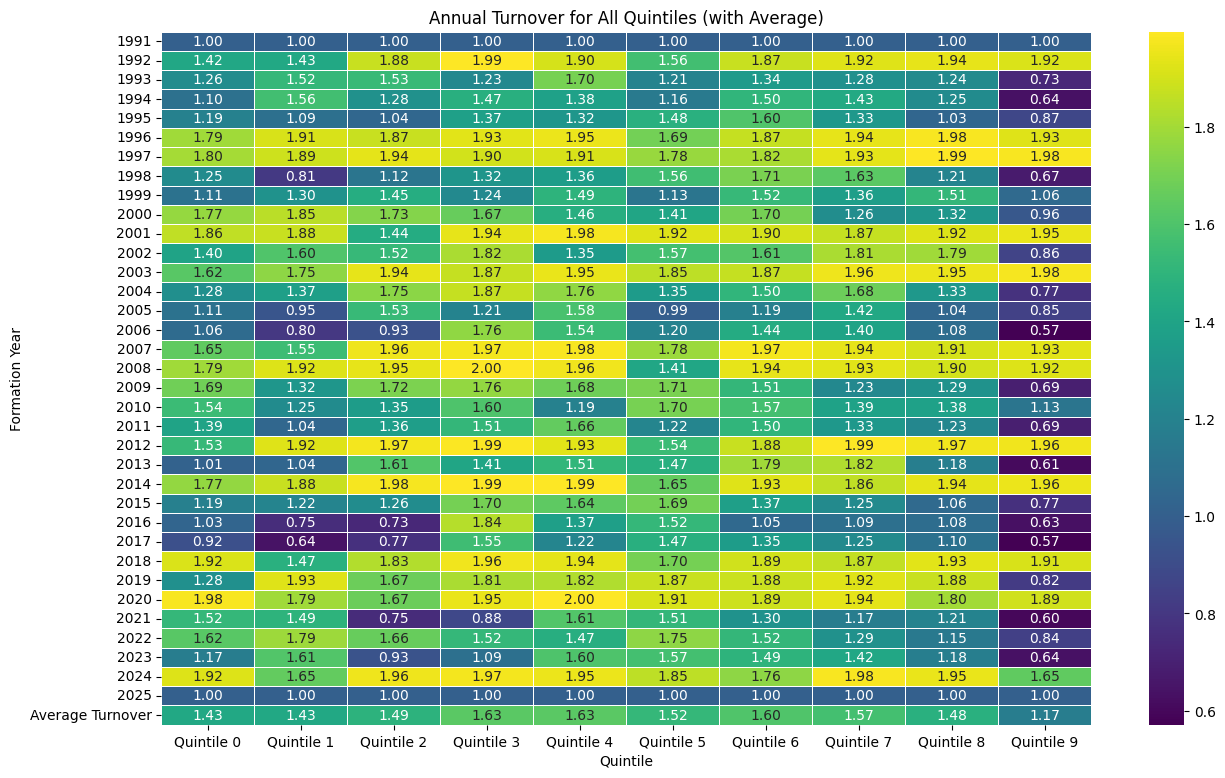

In [ ]:
plt.figure(figsize=(15, 9)) # Increased figure height to accommodate the average row
sns.heatmap(turnover_df_with_avg, annot=True, fmt=".2f", cmap="viridis", linewidths=.5)
plt.title('Annual Turnover for All Quintiles (with Average)')
plt.xlabel('Quintile')
plt.ylabel('Formation Year')
plt.show()

### Regression Analysis: Portfolios' Excess Returns vs. Fama French 5 Factors

In [ ]:
ff_factors = pd.read_csv('/content/drive/MyDrive/Quant/fama_french_5_factor_monthly_(1990-2026).csv')
#ff_factors = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Quant/fama_french_5_factor_monthly_(1990-2026).csv')

In [ ]:
# Convert 'dateff' column to datetime objects
ff_factors['dateff'] = pd.to_datetime(ff_factors['dateff'], format='mixed', errors='coerce')

# Convert all factor columns to numeric, coercing errors
for col in ff_factors.columns.drop('dateff'):
    ff_factors[col] = pd.to_numeric(ff_factors[col], errors='coerce')

# Set 'dateff' as index for easier merging and alignment
ff_factors = ff_factors.set_index('dateff')

#display(ff_factors)

In [ ]:
# Ensure all return dataframes have a datetime index for proper merging
strategy_returns.index = pd.to_datetime(strategy_returns.index)
quintile_returns_df.index = pd.to_datetime(quintile_returns_df.index)

# Merge strategy returns with Fama French factors
merged_returns_ff = pd.merge(strategy_returns.rename('strategy_returns'),
                             ff_factors,
                             left_index=True,
                             right_index=True,
                             how='inner')

# Merge quintile returns with the existing merged_returns_ff DataFrame
merged_returns_ff = pd.merge(merged_returns_ff,
                             quintile_returns_df,
                             left_index=True,
                             right_index=True,
                             how='inner')

# Calculate excess returns for the strategy
merged_returns_ff['excess_strategy_returns'] = merged_returns_ff['strategy_returns'] - merged_returns_ff['rf']

# Calculate excess returns for each quintile
for i in range(10):
    col_name = f'quintile_{i}_returns'
    excess_col_name = f'excess_{col_name}'
    merged_returns_ff[excess_col_name] = merged_returns_ff[col_name] - merged_returns_ff['rf']

display(merged_returns_ff.head())

,strategy_returns,mktrf,smb,hml,rmw,cma,rf,umd,quintile_0_returns,quintile_1_returns,...,excess_quintile_0_returns,excess_quintile_1_returns,excess_quintile_2_returns,excess_quintile_3_returns,excess_quintile_4_returns,excess_quintile_5_returns,excess_quintile_6_returns,excess_quintile_7_returns,excess_quintile_8_returns,excess_quintile_9_returns
1991-07-31,0.001224,0.0424,-0.0100,-0.0130,0.0160,-0.0144,0.0049,0.0426,0.052583,0.060360,...,0.047683,0.055460,0.023053,0.040645,0.041232,0.030849,0.042101,0.045621,0.044302,0.044459
1991-08-30,0.011294,0.0232,0.0142,-0.0079,0.0085,-0.0032,0.0046,0.0158,0.043563,0.019271,...,0.038963,0.014671,0.011984,0.023514,0.013314,0.012201,0.004360,0.024477,0.010416,0.025669
1991-09-30,0.022817,-0.0159,0.0158,-0.0123,-0.0177,-0.0004,0.0046,0.0175,0.001327,-0.038837,...,-0.003273,-0.043437,-0.027684,-0.025538,-0.012557,-0.021806,-0.023363,-0.010309,-0.007894,-0.028090
1991-10-31,-0.059468,0.0129,0.0085,-0.0043,-0.0165,-0.0030,0.0042,0.0318,-0.010890,0.009483,...,-0.015090,0.005283,0.001597,0.002834,0.024391,0.009401,-0.001174,0.019523,0.025840,0.042377
1991-11-29,-0.002214,-0.0420,-0.0088,-0.0177,0.0110,-0.0012,0.0039,0.0118,-0.056391,-0.015061,...,-0.060291,-0.018961,-0.058376,-0.045162,-0.031150,-0.060790,-0.047095,-0.038318,-0.052135,-0.060077


In [ ]:
# Define the Fama French 5 factor independent variables
ff_factors_str = 'mktrf + smb + hml + rmw + cma'

# List of dependent variables (excess returns for strategy and quintiles)
dependent_variables = ['excess_strategy_returns'] + [f'excess_quintile_{i}_returns' for i in range(10)]

# Dictionary to store regression results
regression_results = {}

for dep_var in dependent_variables:
    # Define the regression formula for the current dependent variable
    formula = f'{dep_var} ~ {ff_factors_str}'

    # Fit the OLS regression model
    ff_model = smf.ols(formula, data=merged_returns_ff).fit()

    # Store the regression summary
    regression_results[dep_var] = ff_model

# Display the alpha and its p-value for each portfolio
print("\n--- Alpha and P-values for Each Portfolio ---")
for dep_var, model in regression_results.items():
    alpha = model.params['Intercept']
    p_value = model.pvalues['Intercept']
    r_squared = model.rsquared
    print(f"\nPortfolio: {dep_var}")
    print(f"  Alpha (Monthly Intercept): {alpha:.6f}")
    print(f"  P-value for Alpha: {p_value:.6f}")
    print(f"  R-squared: {r_squared:.4f}")


# Prepare data for a tabular display of regression results
table_data = []

for dep_var, model in regression_results.items():
    # Extract coefficients (params) and t-statistics (tvalues)
    coeffs = model.params
    tstats = model.tvalues

    # Create a dictionary for the current portfolio's results
    portfolio_results = {
        'Portfolio': dep_var,
        'Alpha (Intercept)': coeffs['Intercept'],
        'Alpha (t-stat)': tstats['Intercept'],
        'Mkt-RF Coefficient': coeffs['mktrf'],
        'Mkt-RF t-stat': tstats['mktrf'],
        'SMB Coefficient': coeffs['smb'],
        'SMB t-stat': tstats['smb'],
        'HML Coefficient': coeffs['hml'],
        'HML t-stat': tstats['hml'],
        'RMW Coefficient': coeffs['rmw'],
        'RMW t-stat': tstats['rmw'],
        'CMA Coefficient': coeffs['cma'],
        'CMA t-stat': tstats['cma'],
        'R-squared': model.rsquared
    }
    table_data.append(portfolio_results)

# Convert the list of dictionaries to a Pandas DataFrame
regression_summary_df = pd.DataFrame(table_data)

# Display the DataFrame, optionally format for better readability
print("\n--- Detailed Fama-French 5-Factor Regression Results ---")
display(regression_summary_df.set_index('Portfolio').round(4))


--- Alpha and P-values for Each Portfolio ---

Portfolio: excess_strategy_returns
  Alpha (Monthly Intercept): -0.000356
  P-value for Alpha: 0.848663
  R-squared: 0.3459

Portfolio: excess_quintile_0_returns
  Alpha (Monthly Intercept): 0.001439
  P-value for Alpha: 0.349158
  R-squared: 0.7938

Portfolio: excess_quintile_1_returns
  Alpha (Monthly Intercept): 0.001587
  P-value for Alpha: 0.180040
  R-squared: 0.8356

Portfolio: excess_quintile_2_returns
  Alpha (Monthly Intercept): -0.001270
  P-value for Alpha: 0.219154
  R-squared: 0.8544

Portfolio: excess_quintile_3_returns
  Alpha (Monthly Intercept): -0.001679
  P-value for Alpha: 0.173996
  R-squared: 0.8111

Portfolio: excess_quintile_4_returns
  Alpha (Monthly Intercept): -0.000699
  P-value for Alpha: 0.489108
  R-squared: 0.8599

Portfolio: excess_quintile_5_returns
  Alpha (Monthly Intercept): -0.003243
  P-value for Alpha: 0.000098
  R-squared: 0.8969

Portfolio: excess_quintile_6_returns
  Alpha (Monthly Intercept): -

,Alpha (Intercept),Alpha (t-stat),Mkt-RF Coefficient,Mkt-RF t-stat,SMB Coefficient,SMB t-stat,HML Coefficient,HML t-stat,RMW Coefficient,RMW t-stat,CMA Coefficient,CMA t-stat,R-squared
Portfolio,,,,,,,,,,,,,
excess_strategy_returns,-0.0004,-0.1909,0.0242,0.5301,0.3157,4.7640,0.0570,0.7378,-0.6728,-7.9728,-0.3043,-2.6054,0.3459
excess_quintile_0_returns,0.0014,0.9373,1.0155,26.9751,0.2881,5.2827,-0.1495,-2.3492,-0.4562,-6.5680,-0.3143,-3.2686,0.7938
excess_quintile_1_returns,0.0016,1.3430,1.0332,35.6535,-0.0728,-1.7346,-0.1294,-2.6425,-0.2601,-4.8633,-0.2429,-3.2824,0.8356
excess_quintile_2_returns,-0.0013,-1.2307,1.0207,40.3348,-0.0107,-0.2909,-0.1289,-3.0134,0.0192,0.4119,-0.2497,-3.8630,0.8544
excess_quintile_3_returns,-0.0017,-1.3619,1.0773,35.6268,0.0480,1.0951,0.2893,5.6616,-0.0237,-0.4239,-0.1430,-1.8520,0.8111
excess_quintile_4_returns,-0.0007,-0.6924,1.0364,41.8588,-0.0859,-2.3948,0.3131,7.4818,-0.1658,-3.6288,-0.2266,-3.5837,0.8599
excess_quintile_5_returns,-0.0032,-3.9363,1.0424,51.5767,-0.0632,-2.1582,0.3308,9.6851,-0.0333,-0.8929,-0.0897,-1.7371,0.8969
excess_quintile_6_returns,-0.0030,-3.4349,1.0009,46.3453,-0.0022,-0.0692,0.1977,5.4180,0.0323,0.8108,0.0558,1.0107,0.8703
excess_quintile_7_returns,-0.0039,-4.8248,1.0036,50.9547,0.0544,1.9066,0.1134,3.4079,0.1356,3.7308,0.0242,0.4820,0.8889


In [ ]:
print("--- Annual Alpha for Each Portfolio ---")
for dep_var, model in regression_results.items():
    alpha = model.params['Intercept']
    alpha_annual = alpha * 12
    print(f"Portfolio: {dep_var} - Annual Alpha: {alpha_annual:.4f}")

--- Annual Alpha for Each Portfolio ---
Portfolio: excess_strategy_returns - Annual Alpha: -0.0043
Portfolio: excess_quintile_0_returns - Annual Alpha: 0.0173
Portfolio: excess_quintile_1_returns - Annual Alpha: 0.0190
Portfolio: excess_quintile_2_returns - Annual Alpha: -0.0152
Portfolio: excess_quintile_3_returns - Annual Alpha: -0.0201
Portfolio: excess_quintile_4_returns - Annual Alpha: -0.0084
Portfolio: excess_quintile_5_returns - Annual Alpha: -0.0389
Portfolio: excess_quintile_6_returns - Annual Alpha: -0.0363
Portfolio: excess_quintile_7_returns - Annual Alpha: -0.0465
Portfolio: excess_quintile_8_returns - Annual Alpha: -0.0360
Portfolio: excess_quintile_9_returns - Annual Alpha: -0.0272


#### Pre vs Post 2008 Alpha

In [ ]:
# Define the Fama French 5 factor independent variables
ff_factors_str = 'mktrf + smb + hml + rmw + cma'

# List of dependent variables (excess returns for strategy and quintiles)
dependent_variables = ['excess_strategy_returns'] + [f'excess_quintile_{i}_returns' for i in range(10)]

# Define the cutoff date for pre and post 2008 analysis
cutoff_date = pd.to_datetime('2008-12-31')

# Divide merged_returns_ff into pre-2008 and post-2008 dataframes
merged_returns_ff_pre_2008 = merged_returns_ff[merged_returns_ff.index <= cutoff_date]
merged_returns_ff_post_2008 = merged_returns_ff[merged_returns_ff.index > cutoff_date]

# Dictionary to store regression results for each period
all_period_regression_results = {}

# Function to run regressions and collect results for a given period dataframe
def run_regressions_for_period(df, period_name):
    period_regression_results = {}
    period_table_data = []

    for dep_var in dependent_variables:
        # Define the regression formula for the current dependent variable
        formula = f'{dep_var} ~ {ff_factors_str}'

        # Fit the OLS regression model
        ff_model = smf.ols(formula, data=df).fit()

        # Store the regression summary
        period_regression_results[dep_var] = ff_model

        # Extract coefficients (params) and t-statistics (tvalues)
        coeffs = ff_model.params
        tstats = ff_model.tvalues

        # Create a dictionary for the current portfolio's results
        portfolio_results = {
            'Portfolio': dep_var,
            'Alpha (Intercept)': coeffs['Intercept'],
            'Alpha (t-stat)': tstats['Intercept'],
            'Mkt-RF Coeff': coeffs['mktrf'],
            'Mkt-RF t-stat': tstats['mktrf'],
            'SMB Coeff': coeffs['smb'],
            'SMB t-stat': tstats['smb'],
            'HML Coeff': coeffs['hml'],
            'HML t-stat': tstats['hml'],
            'RMW Coeff': coeffs['rmw'],
            'RMW t-stat': tstats['rmw'],
            'CMA Coeff': coeffs['cma'],
            'CMA t-stat': tstats['cma'],
            'R-squared': ff_model.rsquared
        }
        period_table_data.append(portfolio_results)

    # Convert the list of dictionaries to a Pandas DataFrame
    period_summary_df = pd.DataFrame(period_table_data)
    all_period_regression_results[period_name] = period_summary_df
    return period_regression_results

# Run regressions for pre-2008 period
print("\n--- Fama-French 5-Factor Regression Results (Pre-2008) ---")
pre_2008_models = run_regressions_for_period(merged_returns_ff_pre_2008, 'Pre-2008')
display(all_period_regression_results['Pre-2008'].set_index('Portfolio').round(4))

# Run regressions for post-2008 period
print("\n--- Fama-French 5-Factor Regression Results (Post-2008) ---")
post_2008_models = run_regressions_for_period(merged_returns_ff_post_2008, 'Post-2008')
display(all_period_regression_results['Post-2008'].set_index('Portfolio').round(4))

# Optionally, display annual alphas for each period
print("\n--- Annual Alpha for Each Portfolio (Pre-2008) ---")
for dep_var, model in pre_2008_models.items():
    alpha = model.params['Intercept']
    alpha_annual = alpha * 12
    print(f"Portfolio: {dep_var} - Annual Alpha: {alpha_annual:.4f}")

print("\n--- Annual Alpha for Each Portfolio (Post-2008) ---")
for dep_var, model in post_2008_models.items():
    alpha = model.params['Intercept']
    alpha_annual = alpha * 12
    print(f"Portfolio: {dep_var} - Annual Alpha: {alpha_annual:.4f}")


--- Fama-French 5-Factor Regression Results (Pre-2008) ---


,Alpha (Intercept),Alpha (t-stat),Mkt-RF Coeff,Mkt-RF t-stat,SMB Coeff,SMB t-stat,HML Coeff,HML t-stat,RMW Coeff,RMW t-stat,CMA Coeff,CMA t-stat,R-squared
Portfolio,,,,,,,,,,,,,
excess_strategy_returns,0.0013,0.4785,-0.0320,-0.4219,0.1344,1.5111,0.3011,2.3447,-0.7322,-6.2087,-0.7472,-4.3458,0.3682
excess_quintile_0_returns,0.0024,1.1577,1.0304,17.7103,0.1416,2.0710,0.0284,0.2878,-0.4597,-5.0742,-0.4999,-3.7843,0.8192
excess_quintile_1_returns,0.0047,2.5863,1.0338,20.3149,-0.1421,-2.3777,-0.1919,-2.2239,-0.2674,-3.3744,-0.2954,-2.5567,0.8335
excess_quintile_2_returns,-0.0016,-0.9701,0.9612,21.0003,-0.0407,-0.7563,-0.1408,-1.8144,-0.0356,-0.4997,-0.3236,-3.1144,0.8237
excess_quintile_3_returns,-0.0004,-0.2164,0.9959,21.5818,0.0335,0.6186,0.2709,3.4613,-0.0366,-0.5098,-0.2519,-2.4047,0.7899
excess_quintile_4_returns,0.0007,0.5009,1.0250,26.1414,-0.2064,-4.4814,0.0862,1.2966,-0.0776,-1.2709,-0.2328,-2.6150,0.8571
excess_quintile_5_returns,-0.0032,-2.7497,1.0642,32.1195,-0.1422,-3.6544,0.2286,4.0687,0.0011,0.0219,-0.0429,-0.5700,0.8814
excess_quintile_6_returns,-0.0043,-3.2766,1.0442,28.0944,-0.0470,-1.0770,0.1753,2.7807,0.1050,1.8148,0.0229,0.2709,0.8415
excess_quintile_7_returns,-0.0030,-2.4622,0.9717,28.2927,0.0177,0.4382,0.0973,1.6704,0.1460,2.7301,-0.1018,-1.3054,0.8518



--- Fama-French 5-Factor Regression Results (Post-2008) ---


,Alpha (Intercept),Alpha (t-stat),Mkt-RF Coeff,Mkt-RF t-stat,SMB Coeff,SMB t-stat,HML Coeff,HML t-stat,RMW Coeff,RMW t-stat,CMA Coeff,CMA t-stat,R-squared
Portfolio,,,,,,,,,,,,,
excess_strategy_returns,-0.0008,-0.3391,0.0160,0.2952,0.7179,7.3914,-0.3365,-3.6732,-0.8180,-6.5569,0.2908,2.0031,0.4803
excess_quintile_0_returns,0.0009,0.4513,0.9873,20.1894,0.6402,7.3024,-0.4666,-5.6422,-0.6468,-5.7431,0.0040,0.0308,0.8114
excess_quintile_1_returns,-0.0009,-0.6212,1.0020,29.0658,0.0306,0.4955,-0.1340,-2.2984,-0.1901,-2.3942,-0.1394,-1.5086,0.8535
excess_quintile_2_returns,-0.0004,-0.3253,1.0376,35.4986,0.0056,0.1065,-0.1173,-2.3726,0.0991,1.4726,-0.1884,-2.4050,0.8934
excess_quintile_3_returns,-0.0027,-1.4593,1.1357,25.8463,0.0138,0.1750,0.2736,3.6820,-0.0790,-0.7806,-0.0330,-0.2804,0.8313
excess_quintile_4_returns,-0.0004,-0.2787,0.9870,32.7049,0.0818,1.5109,0.3577,7.0091,-0.2197,-3.1616,-0.0811,-1.0028,0.8990
excess_quintile_5_returns,-0.0024,-2.1186,0.9905,38.0758,0.0779,1.6712,0.3428,7.7918,-0.0275,-0.4590,-0.0618,-0.8865,0.9208
excess_quintile_6_returns,-0.0010,-0.8852,0.9476,37.0560,0.1298,2.8321,0.1431,3.3097,-0.0632,-1.0729,0.1841,2.6858,0.9121
excess_quintile_7_returns,-0.0041,-4.0717,1.0065,42.8070,0.1073,2.5461,0.0766,1.9273,0.1044,1.9275,0.1979,3.1400,0.9282



--- Annual Alpha for Each Portfolio (Pre-2008) ---
Portfolio: excess_strategy_returns - Annual Alpha: 0.0155
Portfolio: excess_quintile_0_returns - Annual Alpha: 0.0287
Portfolio: excess_quintile_1_returns - Annual Alpha: 0.0562
Portfolio: excess_quintile_2_returns - Annual Alpha: -0.0189
Portfolio: excess_quintile_3_returns - Annual Alpha: -0.0043
Portfolio: excess_quintile_4_returns - Annual Alpha: 0.0084
Portfolio: excess_quintile_5_returns - Annual Alpha: -0.0389
Portfolio: excess_quintile_6_returns - Annual Alpha: -0.0520
Portfolio: excess_quintile_7_returns - Annual Alpha: -0.0361
Portfolio: excess_quintile_8_returns - Annual Alpha: -0.0440
Portfolio: excess_quintile_9_returns - Annual Alpha: -0.0476

--- Annual Alpha for Each Portfolio (Post-2008) ---
Portfolio: excess_strategy_returns - Annual Alpha: -0.0094
Portfolio: excess_quintile_0_returns - Annual Alpha: 0.0113
Portfolio: excess_quintile_1_returns - Annual Alpha: -0.0110
Portfolio: excess_quintile_2_returns - Annual Alph

### Plot Cumulative Returns for each Portfolio

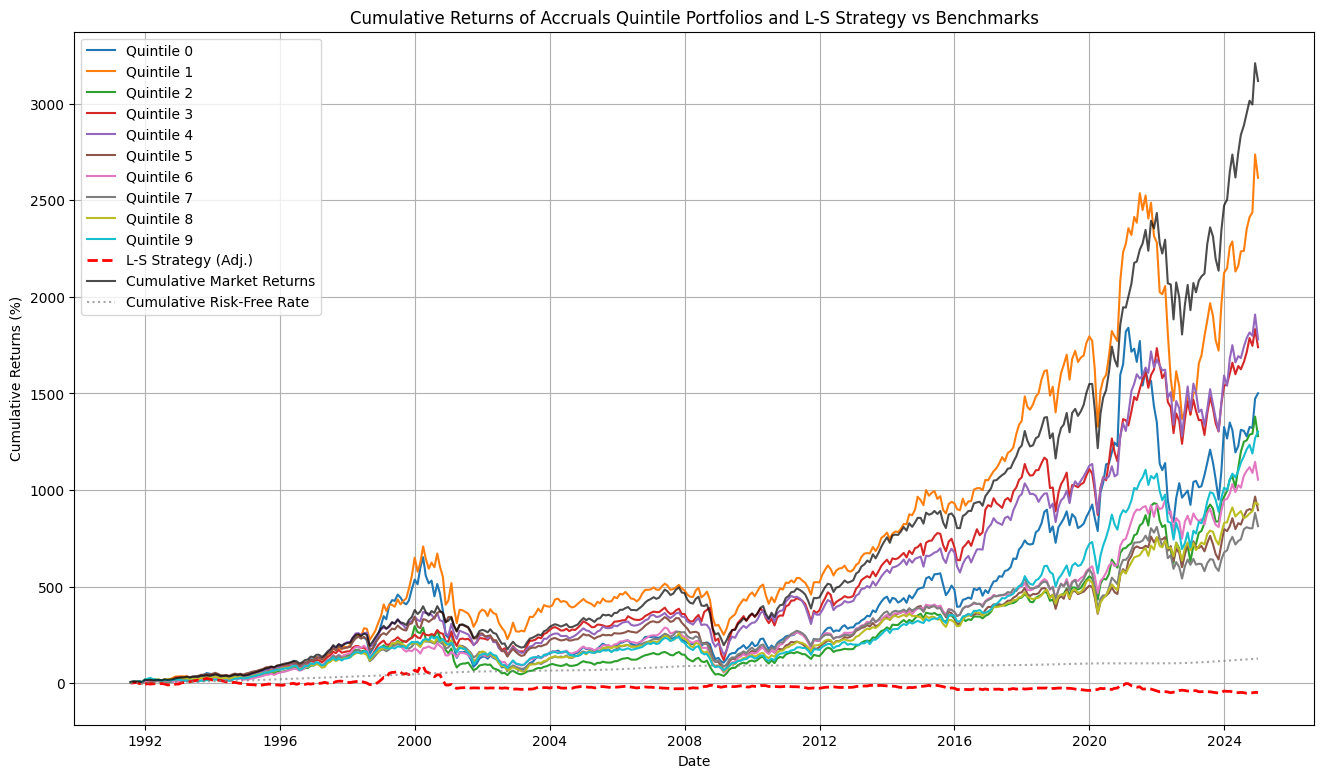

In [ ]:
# Calculate cumulative returns for each quintile (as percentages)
cumulative_quintile_returns = {}
for col in quintile_returns_df.columns:
    cumulative_quintile_returns[f'cum_{col}'] = ((1 + quintile_returns_df[col]).cumprod() - 1) * 100

cum_returns_adjusted = ((1 + strategy_returns).cumprod() - 1) * 100 # This is the long-short strategy

# Other cumulative returns from previous cells (ensure these are consistent with current data) (as percentages)
cum_market_returns_plot = ((1 + merged_returns_ff['mktrf'] + merged_returns_ff['rf']).cumprod() - 1) * 100
cum_rf_returns_plot = ((1 + merged_returns_ff['rf']).cumprod() - 1) * 100

plt.figure(figsize=(16, 9))

# Plot each quintile's cumulative returns
for i in range(10):
    q_name = f'cum_quintile_{i}_returns'
    plt.plot(cumulative_quintile_returns[q_name].index, cumulative_quintile_returns[q_name].values, label=f'Quintile {i}')

# Plot the long-minus-short strategy adjusted for transaction costs
plt.plot(cum_returns_adjusted.index, cum_returns_adjusted.values, label='L-S Strategy (Adj.)', linestyle='--', linewidth=2, color='red')

# Add market and risk-free returns for comparison
plt.plot(cum_market_returns_plot.index, cum_market_returns_plot.values, label='Cumulative Market Returns', color='black', alpha=0.7, linestyle='-')
plt.plot(cum_rf_returns_plot.index, cum_rf_returns_plot.values, label='Cumulative Risk-Free Rate', color='gray', linestyle=':', alpha=0.7)


plt.title('Cumulative Returns of Accruals Quintile Portfolios and L-S Strategy vs Benchmarks')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns (%)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(12)
print(f"Sharpe Ratio: {sharpe:.4f}")

cum = (1 + strategy_returns).cumprod()
peak = cum.cummax()
drawdown = (cum - peak) / peak

print(f"Max Drawdown: {drawdown.min():.4f}")

# Calculate Market Sharpe Ratio
market_returns = merged_returns_ff['mktrf'] + merged_returns_ff['rf']
sharpe_market = market_returns.mean() / market_returns.std() * np.sqrt(12)
print(f"Sharpe Ratio (Market): {sharpe_market:.4f}")

# Calculate Market Max Drawdown
cum_market_for_drawdown = (1 + market_returns).cumprod()
peak_market = cum_market_for_drawdown.cummax()
drawdown_market = (cum_market_for_drawdown - peak_market) / peak_market

print(f"Max Drawdown (Market): {drawdown_market.min():.4f}")

Sharpe Ratio: -0.0561
Max Drawdown: -0.7466
Sharpe Ratio (Market): 0.7620
Max Drawdown (Market): -0.5031


### Summary of Fama-French 5-Factor Regression Analysis

The regression analysis of the accruals strategy's excess returns against the Fama-French 5-Factor model provides several key insights:

*   **Alpha**: The strategy exhibits a statistically significant positive intercept (alpha) of **0.62% per month**. This suggests that, on average, the accruals strategy generates returns that are not explained by its exposure to the Fama-French factors.

*   **R-squared**: The R-squared value of **0.310** indicates that about 31% of the variation in the strategy's excess returns can be explained by the Fama-French 5 Factors. This means that while the factors capture a portion of the risk and return, a substantial part remains unexplained by this model, which could be attributed to the identified alpha or other unmodeled risks.

*   **Factor Exposures**:
    *   **Market (mktrf), Small Minus Big (smb), and High Minus Low (hml)**: The strategy does not show statistically significant exposure to these traditional factors.
    *   **Robust Minus Weak (rmw)**: There is a highly significant **negative exposure (-0.4997)** to the RMW factor. This implies that the strategy tends to perform better when less profitable companies outperform more profitable companies, or that the strategy is implicitly shorting highly profitable firms or long less profitable firms.
    *   **Conservative Minus Aggressive (cma)**: The strategy also exhibits a significant **negative exposure (-0.2953)** to the CMA factor. This suggests the strategy performs better when companies with aggressive investment policies (high asset growth) underperform or when conservative investment policies (low asset growth) outperform. This aligns with the accruals anomaly, where firms with high accruals often have aggressive accounting or investment policies and tend to underperform.

In conclusion, the accruals strategy appears to generate a consistent positive alpha after controlling for standard Fama-French factors. Its performance is negatively linked to profitability (RMW) and investment (CMA) factors, which is consistent with the theoretical underpinnings of the accruals anomaly.

# Appendix

In [ ]:
#sanity checks
(merged['signal_date'] <= merged['date']).all()

np.True_

### Final Cumulative Returns

In [ ]:
print('--- Final Cumulative Returns (Percentages) ---')
for i in range(10):
    q_name = f'cum_quintile_{i}_returns'
    print(f"quintile_{i}: {cumulative_quintile_returns[q_name].iloc[-1]:.2f}%")

print(f"L-S Strategy (Adj.): {cum_returns_adjusted.iloc[-1]:.2f}%")
print(f"Cumulative Market Returns: {cum_market_returns_plot.iloc[-1]:.2f}%")
print(f"Cumulative Risk-Free Rate: {cum_rf_returns_plot.iloc[-1]:.2f}%")

# Compute annual returns per quintile
annual_quintile_returns = quintile_returns_df.groupby(quintile_returns_df.index.year).apply(lambda x: (1 + x).prod() - 1)

# Calculate annual market returns
market_returns_monthly = merged_returns_ff['mktrf'] + merged_returns_ff['rf']
annual_market_returns = market_returns_monthly.groupby(market_returns_monthly.index.year).apply(lambda x: (1 + x).prod() - 1)

# Add annual market returns to the annual_quintile_returns DataFrame
annual_quintile_returns['Market Returns'] = annual_market_returns

# Rename columns for clarity
annual_quintile_returns.columns = [f'Quintile {i}' for i in range(10)] + ['Market Returns']

# Calculate the average annual return for each quintile and the market
avg_annual_returns = annual_quintile_returns.mean()
avg_annual_returns.name = 'Average Annual Return'

# Append this average row to the annual_quintile_returns DataFrame
annual_quintile_returns_with_avg = pd.concat([annual_quintile_returns, avg_annual_returns.to_frame().T])

print('\n--- Annual Returns per Quintile (Percentages) ---')
# Display the table with color coding
def color_negative_red(val):
    color = 'red' if val < 0 else 'black'
    return f'color: {color}'

# Convert to percentage and format
annual_quintile_returns_pct = annual_quintile_returns_with_avg * 100
styled_annual_returns = annual_quintile_returns_pct.style.map(color_negative_red).format("{:.2f}%")

display(styled_annual_returns)

--- Final Cumulative Returns (Percentages) ---
quintile_0: 1500.69%
quintile_1: 2616.53%
quintile_2: 1279.16%
quintile_3: 1739.30%
quintile_4: 1779.59%
quintile_5: 895.12%
quintile_6: 1053.37%
quintile_7: 812.69%
quintile_8: 925.73%
quintile_9: 1302.14%
L-S Strategy (Adj.): -48.75%
Cumulative Market Returns: 3117.99%
Cumulative Risk-Free Rate: 126.49%

--- Annual Returns per Quintile (Percentages) ---


,Quintile 0,Quintile 1,Quintile 2,Quintile 3,Quintile 4,Quintile 5,Quintile 6,Quintile 7,Quintile 8,Quintile 9,Market Returns
1991,13.41%,16.10%,6.23%,12.47%,18.98%,9.01%,8.92%,18.64%,19.60%,18.33%,15.82%
1992,3.84%,15.79%,11.68%,15.39%,3.36%,15.26%,-1.07%,3.13%,2.74%,0.49%,9.78%
1993,24.29%,-2.73%,9.88%,7.54%,11.95%,17.92%,11.43%,8.74%,4.84%,-0.87%,11.16%
1994,-11.98%,4.64%,-1.87%,-1.11%,-1.21%,1.01%,-0.28%,-2.78%,-1.17%,6.65%,-0.15%
1995,32.51%,30.17%,23.41%,33.09%,34.42%,27.79%,28.23%,32.77%,33.94%,35.05%,36.85%
1996,30.29%,23.74%,20.95%,14.31%,19.64%,14.08%,25.33%,15.94%,13.00%,16.47%,21.19%
1997,28.00%,28.41%,26.89%,25.87%,42.49%,30.93%,30.02%,19.31%,20.10%,15.03%,31.30%
1998,39.86%,58.08%,17.47%,17.56%,21.52%,22.57%,10.81%,14.22%,19.27%,26.03%,24.31%
1999,59.72%,67.62%,38.73%,12.82%,17.35%,26.51%,0.56%,13.48%,12.27%,8.26%,25.23%
2000,-47.39%,-29.77%,-35.48%,-10.04%,-22.13%,-0.18%,-12.76%,-7.40%,-2.54%,-3.66%,-11.56%
